Import needed libraries

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

Data transform and normalizatoin

In [11]:
#to tensor and normalized with the mean and standard deviation hardcoded in
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.permute(0, 2, 1)),
    transforms.Normalize((0.1736,), (0.3317,)) #check where this is from
])

In [12]:
#load data sets
train_dataset = datasets.EMNIST(root='./data', split = 'balanced', train=True, transform=transform, download=True)
test_dataset = datasets.EMNIST(root='./data', split = 'balanced', train=False, transform=transform, download=True)

#loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [33]:
label_map = {i: cls for i, cls in enumerate(train_dataset.classes)}

In [13]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 47)#47 is for the number of classes

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

model = CNNModel()

In [17]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 47)#47 is for the number of classes

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 3 * 3)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

model = CNNModel()

In [18]:
# --- Loss and Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [22]:
# --- Training Loop ---
epochs = 2
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [1/2], Loss: 0.2231
Epoch [2/2], Loss: 0.2155


In [23]:
# --- Evaluation ---
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# Accuracy & Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.77      0.70       400
           1       0.56      0.68      0.61       400
           2       0.90      0.90      0.90       400
           3       0.99      0.99      0.99       400
           4       0.96      0.94      0.95       400
           5       0.95      0.90      0.93       400
           6       0.93      0.95      0.94       400
           7       0.98      0.99      0.98       400
           8       0.93      0.96      0.95       400
           9       0.68      0.87      0.77       400
          10       0.97      0.99      0.98       400
          11       0.97      0.97      0.97       400
          12       0.97      0.95      0.96       400
          13       0.94      0.92      0.93       400
          14       0.98      0.98      0.98       400
          15       0.68      0.64      0.66       400
          16       0.94      0.95      0.95       400
   

In [24]:
# Save the entire model
torch.save(model, 'model.pt')

In [25]:
torch.save(model.state_dict(), 'model_weights.pt')

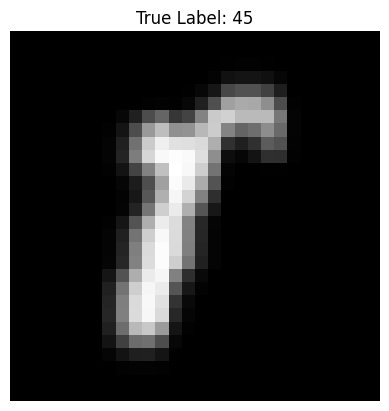

Predicted Class: r


In [49]:
sample_img, sample_label = test_dataset[19]
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title(f"True Label: {sample_label}")
plt.axis('off')
plt.show()

sample_tensor = sample_img.unsqueeze(0)
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output).item()
    print(f"Predicted Class: {label_map[predicted_class]}")

In [46]:
label_map

{0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9',
 10: 'A',
 11: 'B',
 12: 'C',
 13: 'D',
 14: 'E',
 15: 'F',
 16: 'G',
 17: 'H',
 18: 'I',
 19: 'J',
 20: 'K',
 21: 'L',
 22: 'M',
 23: 'N',
 24: 'O',
 25: 'P',
 26: 'Q',
 27: 'R',
 28: 'S',
 29: 'T',
 30: 'U',
 31: 'V',
 32: 'W',
 33: 'X',
 34: 'Y',
 35: 'Z',
 36: 'a',
 37: 'b',
 38: 'd',
 39: 'e',
 40: 'f',
 41: 'g',
 42: 'h',
 43: 'n',
 44: 'q',
 45: 'r',
 46: 't'}

In [56]:
import cv2
import torch
import torch.nn as nn
import numpy as np

# -------------------------
# EMNIST LABELS (balanced split)
# -------------------------
emnist_labels = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

# -------------------------
# MODEL (your CNN)
# -------------------------
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 47)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 3 * 3)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

model = CNNModel()

# LOAD YOUR TRAINED WEIGHTS HERE
model.load_state_dict(torch.load("/content/model_weights.pt"))

model.eval()

# -------------------------
# PREPROCESSING
# -------------------------
def preprocess_image(path):
    img = cv2.imread(path, 0)

    # blur
    img = cv2.GaussianBlur(img, (5,5), 0)

    # adaptive threshold
    img = cv2.adaptiveThreshold(
        img, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        15, 8
    )

    # close gaps in strokes
    kernel = np.ones((3,3), np.uint8)
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

    return img

# -------------------------
# PAD + CENTER
# -------------------------
def pad_and_center(img):
    h, w = img.shape
    size = max(h, w)
    padded = np.zeros((size, size), dtype=np.uint8)

    y_offset = (size - h) // 2
    x_offset = (size - w) // 2

    padded[y_offset:y_offset+h, x_offset:x_offset+w] = img
    return padded

# -------------------------
# SEGMENT CHARACTERS
# -------------------------
def segment_characters(img):
    contours, _ = cv2.findContours(
        img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = [cv2.boundingRect(c) for c in contours]

    # sort top-to-bottom, then left-to-right
    boxes = sorted(boxes, key=lambda b: (b[1] // 50, b[0]))

    chars = []
    for x, y, w, h in boxes:

        # filter noise
        if w < 10 or h < 10:
            continue

        roi = img[y:y+h, x:x+w]

        # pad and resize
        roi = pad_and_center(roi)
        roi = cv2.resize(roi, (28, 28))

        # normalize
        roi = roi.astype(np.float32) / 255.0
        roi = torch.tensor(roi).unsqueeze(0)

        # FIX EMNIST ORIENTATION
        roi = torch.rot90(roi, 1, [1,2])
        roi = torch.flip(roi, [2])

        chars.append(roi)

    return chars

# -------------------------
# PREDICT TEXT
# -------------------------
def assemble_text(chars, model):
    text = ""

    with torch.no_grad():
        for img in chars:
            img = img.unsqueeze(0)
            out = model(img)

            pred = torch.argmax(out, dim=1).item()

            # map to character
            if pred < len(emnist_labels):
                text += emnist_labels[pred]
            else:
                text += "?"

    return text

# -------------------------
# FULL PIPELINE
# -------------------------
def run_ocr(image_path):
    processed = preprocess_image(image_path)
    chars = segment_characters(processed)

    if len(chars) == 0:
        return "No characters detected"

    text = assemble_text(chars, model)
    return text

# -------------------------
# TEST
# -------------------------
result = run_ocr("/content/two.png")
print("Predicted text:", result)

Predicted text: 8
